# Environment Setup

## Install dependencies

In [159]:
# Installing my cv packages

!pip install -q ultralytics opencv-python

## Libraries

In [160]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import ultralytics

from google.colab import files
from ultralytics import YOLO
from IPython.display import Video

## Check GPU

In [161]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [162]:
print("OpenCV:", cv2.__version__)
print("Ultralytics:", ultralytics.__version__)

OpenCV: 5.0.0
Ultralytics: 8.4.148


# Load YOLO model

In [163]:
yolo_model = YOLO("yolo11n.pt")   # Loading YOLO 11n

In [164]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Running on:", device)

Running on: cuda


#Loading Test Video

In [165]:
# # Testing the pretrained model
# uploaded = files.upload()   # needed only for the first upload

In [166]:
video_path = "/content/854671-hd_1920_1080_25fps.mp4"
cap = cv2.VideoCapture(video_path)  # to read the video frame by frame
print("Video opened:", cap.isOpened())

Video opened: True


# Single Frame Detection Test

In [167]:
ret, frame = cap.read()    # Read first frame
print("Frame loaded:", ret)

Frame loaded: True


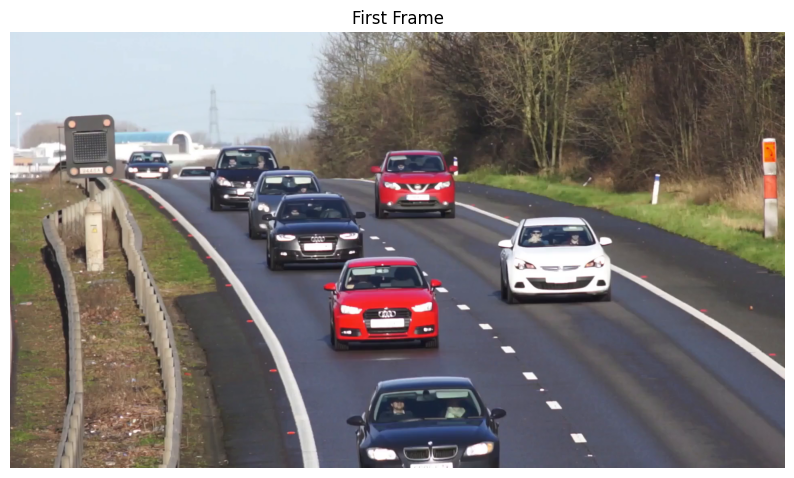

In [168]:
# Displaying first frame
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("First Frame")
plt.show()

## Object detection

In [169]:
# Defining the vehicle class

vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}
print(vehicle_classes)

{2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [170]:
results = yolo_model(
    frame,
    device=device,
    classes=list(vehicle_classes.keys()),
    conf=0.35,
    verbose=False
)

In [ ]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

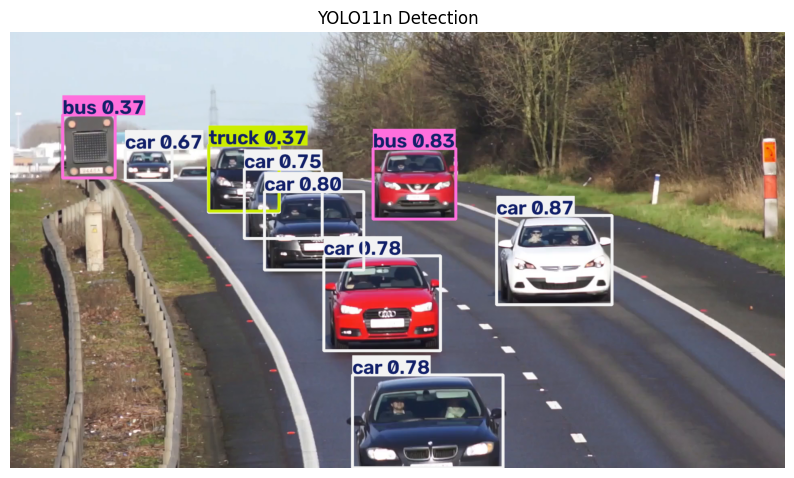

In [171]:
# Displaying what yolo detected
annotated_frame = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO11n Detection")
plt.show()

# Vehicle class Filtering and Counting

In [172]:
# Defining the vehicle class

vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}
print(vehicle_classes)

{2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [173]:
# Count the vehicles
boxes = results[0].boxes

vehicle_count = 0

for i in range(len(boxes)):
    class_id = int(boxes.cls[i].item())

    if class_id in vehicle_classes:
        vehicle_count += 1

print("Vehicles detected:", vehicle_count)

Vehicles detected: 10


In [174]:
# Displaying only vehicle detection
vehicle_detections = []

for i in range(len(boxes)):
    class_id = int(boxes.cls[i].item())

    if class_id in vehicle_classes:
        vehicle_detections.append(i)

print("Vehicle detections:", len(vehicle_detections))

Vehicle detections: 10


#Full Video Capture

In [175]:
# Detect vehicles throughout the video
# Reopen video capture
cap.release()
cap = cv2.VideoCapture(video_path)
print("Video opened:", cap.isOpened())

Video opened: True


In [176]:
# Set up output writer
output_path = "/content/traffic_yolo_output_4.mp4"

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

In [177]:
# Processing the complete video
frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = yolo_model(
        frame,
        device=device,
        verbose=False
    )

    annotated_frame = results[0].plot()

    out.write(annotated_frame)

    frame_count += 1

print("Frames processed:", frame_count)

Frames processed: 1501


In [178]:
# Close the video files

cap.release()
out.release()

#Preview Annotated Output


In [ ]:
# Watch the result

Video(output_path, embed=True)

Buffered data was truncated after reaching the output size limit.